# Important Packages

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Set global font sizes

In [59]:
import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 12,             # Base font size
    'axes.titlesize': 14,        # Title size of each subplot
    'axes.labelsize': 12,        # X and Y axis label size
    'xtick.labelsize': 12,       # X tick label size
    'ytick.labelsize': 12,       # Y tick label size
    'legend.fontsize': 12,       # Legend text size
    'figure.titlesize': 12       # Main figure title size
})

# Problem:
## Replenishment process: $\emptyset \xrightarrow{\lambda_1 = e^{\mu}} X$ and 
## Reaction process: $X \xrightarrow{\lambda_2} Y$

# - The Gillespie Algorithm

In [60]:
# ============================================================
# Gillespie Algorithm
# ============================================================
def gillespie_algorithm(init_state, vectors, propensities, T):  
    state = np.array(init_state)
    time = 0.0
    times = [time]
    states = [state.copy()]
    
    while time < T:
        a = np.array(propensities(state))
        a0 = np.sum(a)
        if a0 == 0:
            break

        r1, r2 = np.random.uniform(0, 1, 2)
        t = (1/a0) * np.log(1/r1)
        cumsum_a = np.cumsum(a)
        vector_index = np.searchsorted(cumsum_a, r2 * a0)

        time += t
        state += vectors[vector_index]

        times.append(time)
        states.append(state.copy())
    
    return np.array(times), np.array(states)


# ============================================================
# Gene expression model
#   emptyset  --mu-->  X
#   X  --lambda-->  Y
# ============================================================
def gene_propensities(state, mu):
    X, Y = state
    lam = 1
    return [mu, lam*X]


def make_propensity(mu):
    return lambda state: gene_propensities(state, mu)


# ============================================================
# Monte Carlo estimator for E[Y(T)]
# ============================================================
def estimate_E_YT(mu, init_state, vectors, T, num_runs):
    Y_T = np.zeros(num_runs)

    prop_fn = make_propensity(mu)

    for i in range(num_runs):
        _, states = gillespie_algorithm(init_state, vectors, prop_fn, T)
        Y_T[i]= states[-1, 1]                         # final state count
        
    return Y_T

# =============================================================================
# MC estimator for E[integral_0^T X(t)] ~ E[\sum_{i=0}^{N-1} X_i(t_{i+1}-t_i)]
# =============================================================================
def estimate_integral_EX(mu, init_state, vectors, T, num_runs):
    prop_fn = make_propensity(mu)
    integrals = np.zeros(num_runs)

    for i in range(num_runs):
        times, states = gillespie_algorithm(init_state, vectors, prop_fn, T)
        integrals[i] = np.sum(states[:-1, 0] * np.diff(times))
    return integrals

# =============================================================================
# MC estimator for E[X(t)] and E(Y(t))
# =============================================================================
def estimate_EX_EY_t(mu, init_state, vectors, T, num_runs, grid_size):
    prop_fn = make_propensity(mu)
    # Common time grid
    t_grid = np.linspace(0, T, grid_size)
    
    # Storage for MC paths
    X_paths = np.zeros((num_runs, grid_size))
    Y_paths = np.zeros((num_runs, grid_size))

    for i in range(num_runs):
        times, states = gillespie_algorithm(init_state, vectors, prop_fn, T)
        X = states[:, 0]
        Y = states[:, 1]

        # Step-function interpolation
        X_interp = np.interp(t_grid, times, X)
        Y_interp = np.interp(t_grid, times, Y)

        X_paths[i, :] = X_interp
        Y_paths[i, :] = Y_interp

    # Monte Carlo expectations
    E_X_t = np.mean(X_paths, axis=0)
    E_Y_t = np.mean(Y_paths, axis=0)

    return t_grid, E_X_t, E_Y_t    #, X_paths, Y_paths

# =============================================================================
# Exact estimator for E[X(t)] and E(Y(t))
# =============================================================================
def exact_EX_EY_t(mu, lam, x_0, y_0, t_grid):
    EX = (x_0 - mu/lam) * np.exp(-lam * t_grid) + mu/lam
    EY = y_0 - (x_0 - mu/lam)*(np.exp(-lam * t_grid) - 1) + mu * t_grid
    return EX, EY

# - Print out 

In [61]:
# ============================================================
# Parameters
# ============================================================
x_0, y_0 = 10, 0
init_state = [x_0, y_0]                   # initial X, Y
vectors = [(+1, 0),                     # emptyset → X
           (-1, +1),                    # X → Y
                ]

Demand = 30                            # Customer demand
T = 1                                  # final time
num_runs = 1000                        # Monte Carlo runs
B = 5000                               # Number of bootstrap samples
lam = 1
mu = 2
prop_fn = make_propensity(mu)
# prop_fn = make_propensity(np.exp(mu))

grid_size = 1000
t_grid = np.linspace(0, T, grid_size)

# ============================================================
# Run MC Gillespie Algorithm
# ============================================================
times, states = gillespie_algorithm(init_state, vectors, prop_fn, T)  

EX_exact, EY_exact = exact_EX_EY_t(mu, lam, x_0, y_0, t_grid)

t_grid, E_X_t, E_Y_t = estimate_EX_EY_t(mu, init_state, vectors, T, num_runs, grid_size)


# - Plot comparison for the MC and the exact solution for $\mathbb{E}\left(X(t;\mu)\right)$ 

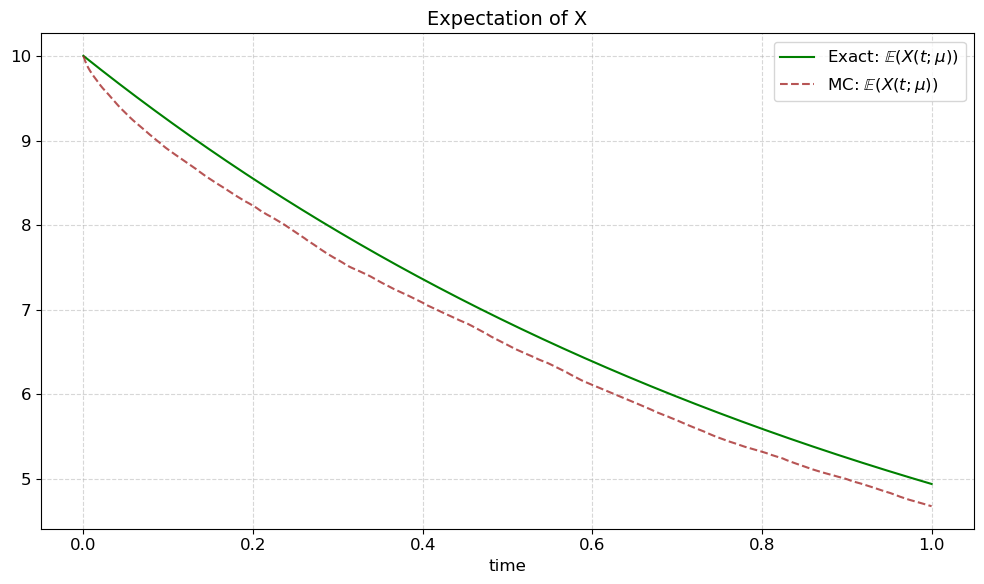

In [62]:
# -------------------------------
# Plot comparison for the MC for X(t) and the exact for X(t)
# -------------------------------
plt.figure(figsize=(10, 6))
plt.plot(t_grid, EX_exact, color='green', label=r"Exact: $\mathbb{E}\left(X(t;\mu)\right)$")
plt.plot(t_grid, E_X_t, '--', color='brown', label=r"MC: $\mathbb{E}\left(X(t;\mu)\right)$", alpha=0.8)
plt.xlabel("time")
plt.title(r"Expectation of X")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# - Plot comparison for the MC and the exact solution for $\mathbb{E}\left(Y(T;\mu)\right)$ 

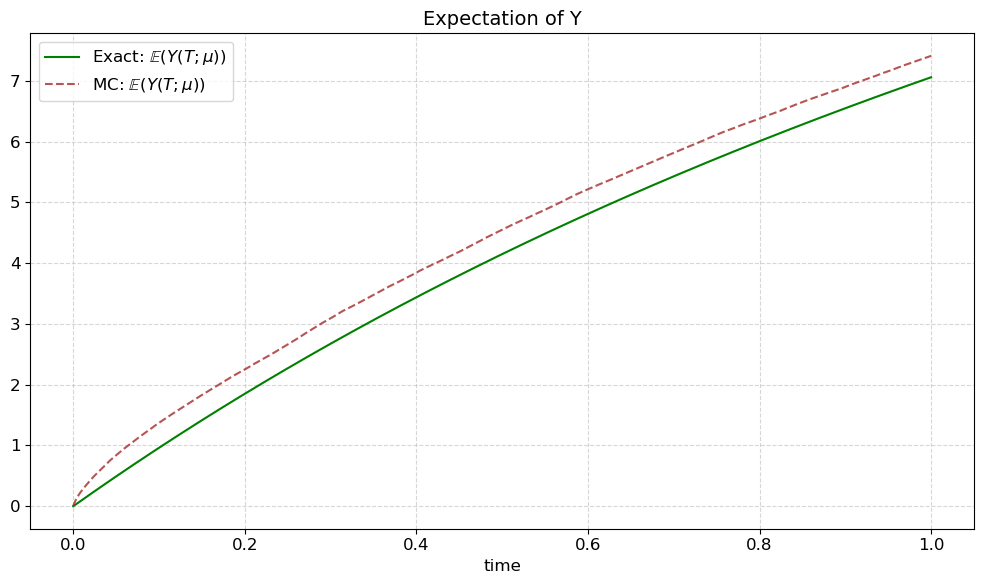

In [63]:
# -------------------------------
# Plot comparison for the MC for Y(t) and the exact for Y(t)
# -------------------------------
plt.figure(figsize=(10, 6))
plt.plot(t_grid, EY_exact, color='green', label=r"Exact: $\mathbb{E}\left(Y(T;\mu)\right)$")
plt.plot(t_grid, E_Y_t, '--', color='brown', label=r"MC: $\mathbb{E}\left(Y(T;\mu)\right)$", alpha=0.8)
plt.xlabel("time")
plt.title(r"Expectation of Y")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# - To know the optimal $\mu$ at $\mathbb{E}\left(Y(T;\mu)\right) \ge M_T$ using Gillespie Algorithm

# - Bootstrap with Linear fit

In [64]:
def bootstrap_regression(mu_values, init_state, vectors, T, num_runs, Demand, B):

    Y_T_mu = {}
    EY_values = {}

    # ==================== Precompute E(Y(T) for each mu ====================
    for mu in mu_values:
        Y_T = estimate_E_YT(mu, init_state, vectors, T, num_runs)
        Y_T_mu[mu] = Y_T
        EY_values[mu] = np.mean(Y_T)

    # ==================== store raw EY curve ====================
    EY_array = np.array([EY_values[mu] for mu in mu_values])

    # ==================== Bootstrap ====================
    mu_star_samples = np.zeros(B)
    Y_fit = np.zeros((B, len(mu_values)))
    n = num_runs

    for b in range(B):
        EY_boot = []

        # =============== compute EY for each mu using bootstrap ================
        for mu in mu_values:
            samples = np.random.choice(Y_T_mu[mu], size=n, replace=True)
            EY_boot.append(np.mean(samples))

        EY_boot = np.array(EY_boot)

        # ==================== Linear regression ====================
        a1, a0 = np.polyfit(mu_values, EY_boot, 1)

        # ==================== store results (Y_fit = a1*mu + a0) ====================
        Y_fit[b, :]  = a1*mu_values + a0


        # ==================== Solve for mu* ====================
        if a1 != 0:
            mu_star = (Demand - a0)/a1
            mu_star_samples[b] = mu_star 

    return Y_fit, EY_array, np.array(mu_star_samples)

# - Exact optimal mu
def exact_optimal_mu(x_0, y_0, T, lam, Demand):
    A = T + ((np.exp(-lam*T)-1)/lam)
    B = Demand + (x_0*(np.exp(-lam*T)-1)) - y_0

    # exact optimal mu
    mu_star = B/A
    return mu_star

# - Print out for linear fit

In [65]:
# # ============================================================
# # Parameters
# # ============================================================
mu_values = np.linspace(50, 70, 60)          

mu_star = exact_optimal_mu(x_0, y_0, T, lam, Demand)
Y_fit, EY_values, mu_star_samples = bootstrap_regression(mu_values, init_state, vectors, T, num_runs, Demand, B)

# - Plot

In [93]:
plt.figure(figsize=(10, 6))
plt.scatter(mu_values, EY_values, color='blue', label=r"$\mathbb{E}(Y(T;\mu))$")
plt.plot(mu_values, Y_fit.mean(axis=0), color='black', label="Linear fit")
plt.axhline(Demand, color='red', linestyle='--', label=r'$M_T$')

CI = np.quantile(mu_star_samples, [0.025, 0.975])                                              # 95% CI
plt.axvspan(CI[0], CI[1], color='Teal', alpha=0.5, label=fr'$95\%$ CI for $\mu^\ast = [{CI[0]:.2f}, {CI[1]:.2f}]$')

plt.xlabel(r"$\mu$")
plt.ylabel(r"Values")
# plt.title("Linear Regression Fit")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# - Histogram

In [92]:
n = len(mu_star_samples)
bins = int(np.ceil(np.sqrt(n)))
plt.figure(figsize=(10, 6))
plt.hist(mu_star_samples, bins=bins, density=True, color ='gray',edgecolor='black', alpha=1)

# KDE
kde = gaussian_kde(mu_star_samples, bw_method=0.5)
x = np.linspace(min(mu_star_samples), max(mu_star_samples), 300)
plt.plot(x, kde(x), color="blue", linewidth=1.5, label="Kernel density curve with bandwidth$=0.5$")

plt.title(r"Bootstrap distribution of optimal $\mu$")
plt.xlabel(r"$\mu^\ast$")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Plot for $\mathbb{E}(Y(T;\mu))= M_{T}$ and Distribution of the optimal mu

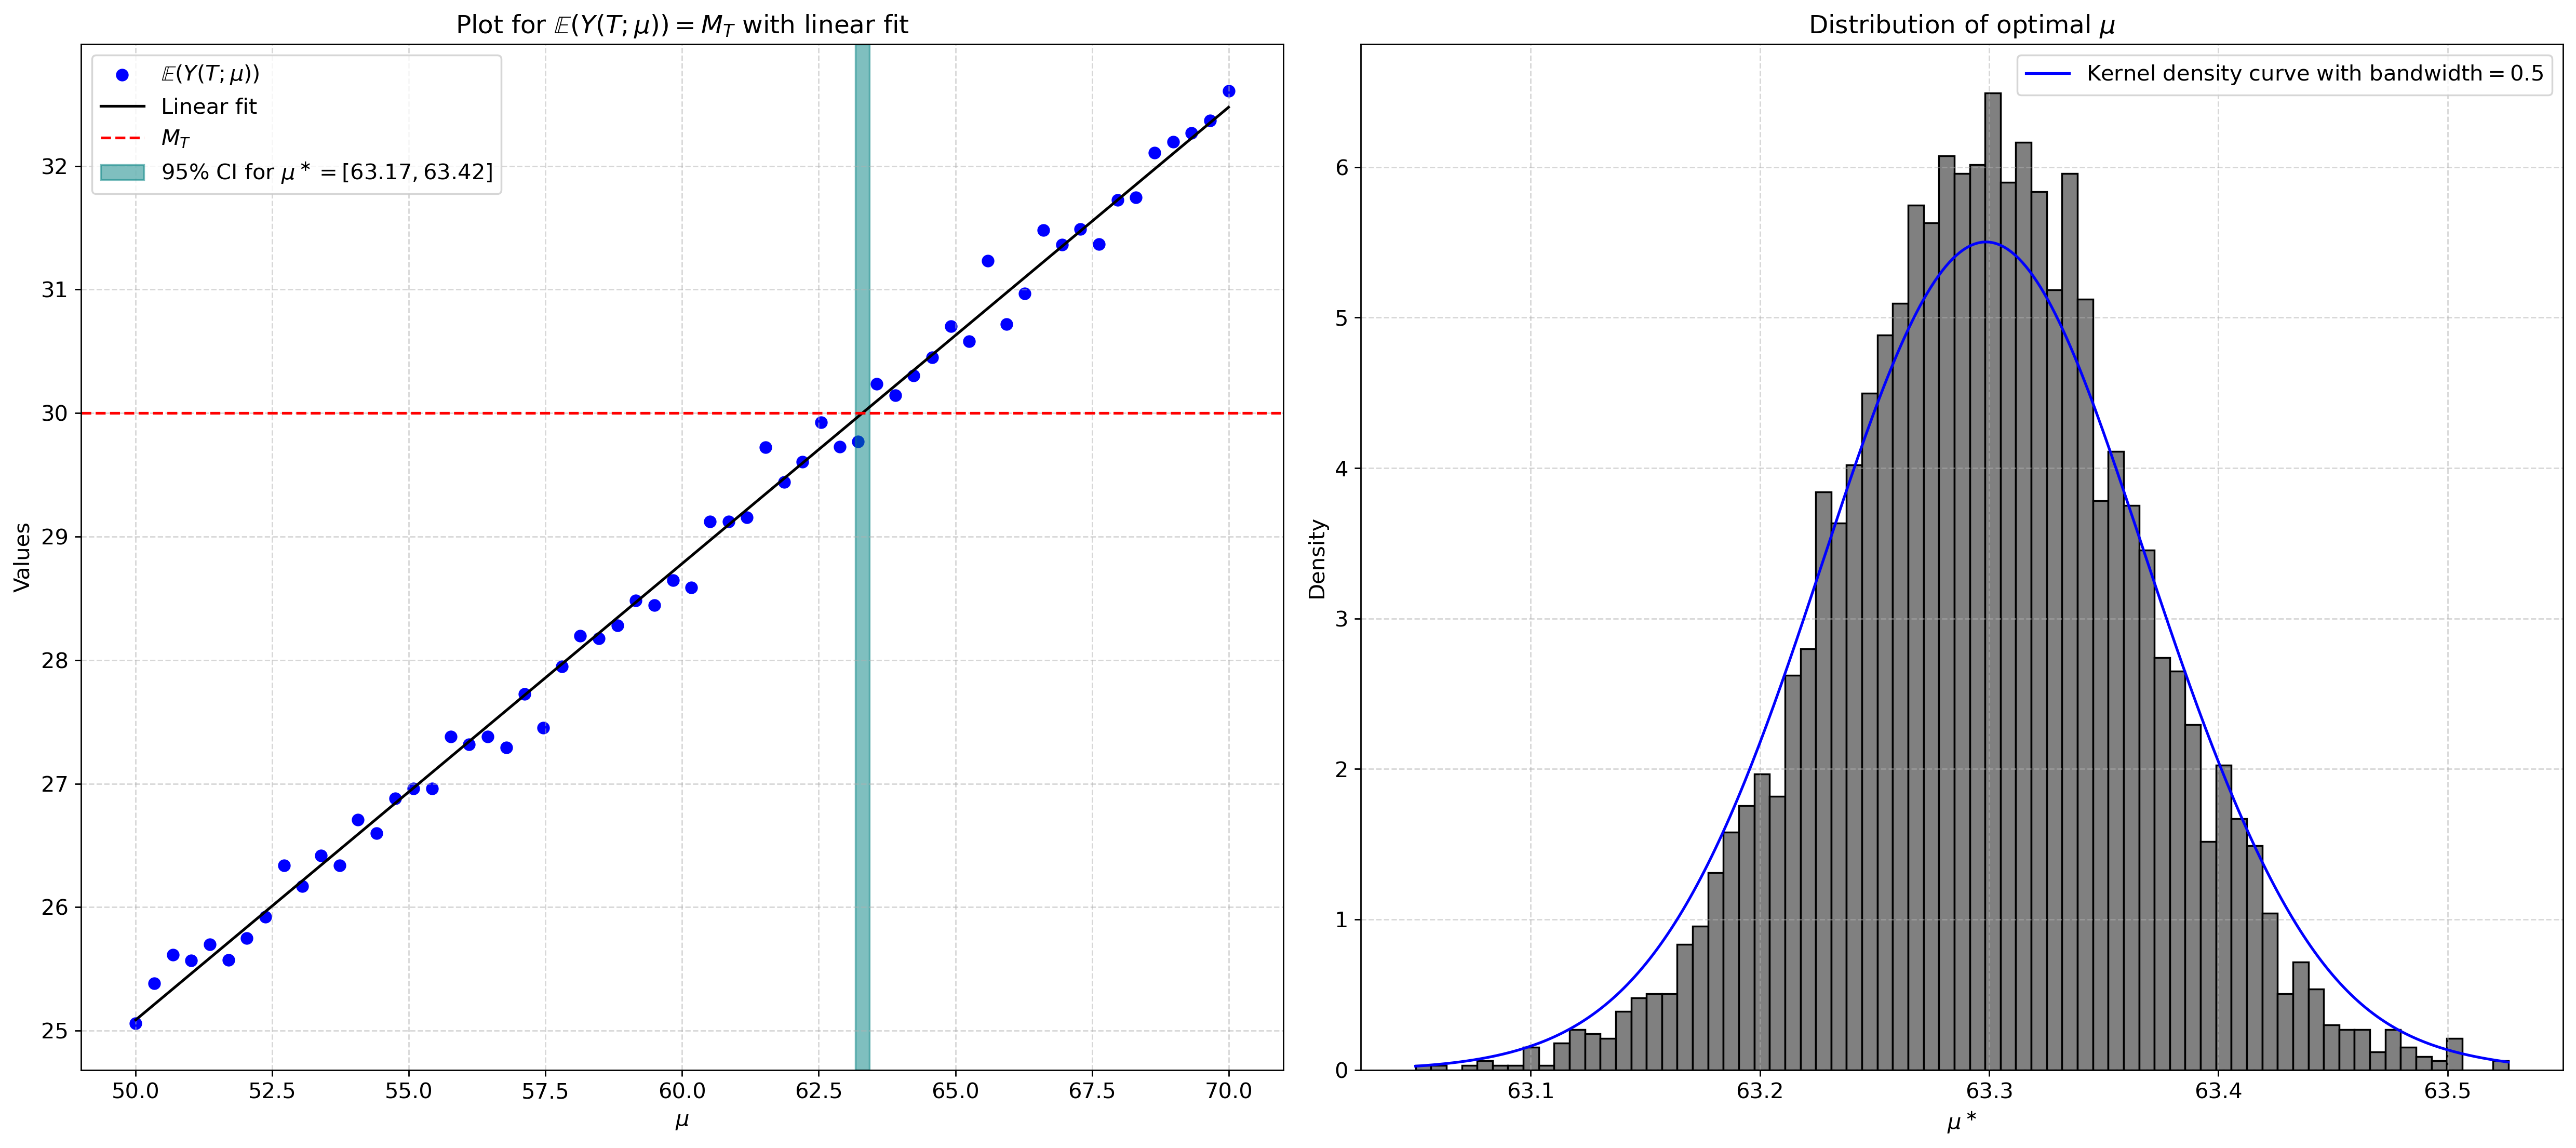

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9), dpi=250)

# ============================================================
#  LEFT PANEL — Linear Regression Fit
# ============================================================
ax = axes[0]

ax.scatter(mu_values, EY_values, color='blue', label=r"$\mathbb{E}(Y(T;\mu))$")
ax.plot(mu_values, Y_fit.mean(axis=0), color='black', label="Linear fit")
ax.axhline(Demand, color='red', linestyle='--', label=r'$M_T$')

CI = np.quantile(mu_star_samples, [0.025, 0.975])                                              # 95% CI
ax.axvspan(CI[0], CI[1], color='Teal', alpha=0.5, label=fr'$95\%$ CI for $\mu^\ast = [{CI[0]:.2f}, {CI[1]:.2f}]$')

ax.set_xlabel(r"$\mu$")
ax.set_ylabel("Values")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()
ax.set_title(r"Plot for $\mathbb{E}(Y(T;\mu)) = M_T$ with linear fit")


# ============================================================
#  RIGHT PANEL — Histogram
# ============================================================
ax = axes[1]

n = len(mu_star_samples)
bins = int(np.ceil(np.sqrt(n)))
ax.hist(mu_star_samples, bins=bins, density=True, color ='gray',edgecolor='black', alpha=1)

# KDE
kde = gaussian_kde(mu_star_samples, bw_method=0.5)
x = np.linspace(min(mu_star_samples), max(mu_star_samples), 300)
ax.plot(x, kde(x), color="blue", linewidth=1.5, label="Kernel density curve with bandwidth$=0.5$")

ax.set_title(r"Distribution of optimal $\mu$")
ax.set_xlabel(r"$\mu^\ast$")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)


# ============================================================
#  Formatting
# ============================================================
plt.tight_layout()
plt.savefig("Optimise_mu1_Gillespie.png", format='png', bbox_inches='tight')
plt.show()

# - To Find the optimal $\mu$ 
## Objective function  $\min_{\mu \ge 0} J(\mu) = \frac{1}{2}\left[\mathbb{E}(Y(T))- M_T\right]^2 + \alpha \mu$ using Gillespie Algorithm

# - Bootstrap with Quadratic fit

In [69]:
# ============================================================
# Bootstrap estimator for mu*
# ============================================================
def bootstrap_quadratic_fit1(mu_values, init_state, vectors, T, num_runs, Demand, alpha, B):
    Y_T_mu1 = {}
    
    for mu in mu_values:
        Y_T1 = estimate_E_YT(mu, init_state, vectors, T, num_runs)
        Y_T_mu1[mu] = Y_T1

# ============================================================
    # Bootstrap resamples with replacement
# ============================================================
    mu_star_samples1 = np.zeros(B)
    Y_Q_fit1 = np.zeros((B, len(mu_values)))
    n = num_runs
    
    for b in range(B):
        J_mu_boot1 = []
        
        for mu in mu_values:
            samples1 = np.random.choice(Y_T_mu1[mu], size=n, replace=True)
            EY_T_value1 = np.mean(samples1)
            J_mu1 = 0.5*(EY_T_value1 - Demand)**2 + alpha * mu
            J_mu_boot1.append(J_mu1)
            
        J_mu_boot1 = np.array(J_mu_boot1)

        # ---------- Quadratic fit ----------
        a2, a1, a0 = np.polyfit(mu_values, J_mu_boot1, 2)

        # store results a_0 + a_1*mu + a_2*mu^2
        Y_Q_fit1[b, :]  = a2*mu_values**2 + a1*mu_values + a0  
        
        # ============================================================
        # Optimal mu
        # ============================================================    
        mu_star_samples1[b] = - a1/(2*a2)
                
    return Y_Q_fit1, J_mu_boot1, np.array(mu_star_samples1)

# - Exact optimal mu
def exact_optimal_mu1(x_0, y_0, T, lam, alpha, Demand):
    A = T + ((np.exp(-lam*T)-1)/lam)
    B = Demand + (x_0*(np.exp(-lam*T)-1)) - y_0

    # exact optimal mu
    mu_star1 = (1/A)*(B -(alpha/A))
    return mu_star1

# - Print Out

In [70]:

# # ============================================================
# # Parameters
# # ============================================================
alpha = 0.5                     # control penalty
mu_values = np.linspace(20, 70, 60)

mu_star1 = exact_optimal_mu1(x_0, y_0, T, lam, alpha, Demand)
Y_Q_fit1, J_mu_boot1, mu_star_samples1 = bootstrap_quadratic_fit1(mu_values, init_state, vectors, T, num_runs, Demand, alpha, B)


# - Plot

In [91]:
# ============================================================
# Plot mu vs J(mu) and Quadratic fit
# ============================================================
plt.figure(figsize=(10, 6))

plt.scatter(mu_values, J_mu_boot1, color='blue', label=r"$J(\mu)$")

plt.plot(mu_values, Y_Q_fit1.mean(axis=0), color ='black', label=r'Quadratic fit')

CI1 = np.quantile(mu_star_samples1, [0.025, 0.975])        # 95% CI
plt.axvspan(CI1[0], CI1[1], color='Teal', alpha=0.5, label=fr'$95\%$ CI for $\mu^\ast = [{CI1[0]:.2f}, {CI1[1]:.2f}]$')

plt.xlabel(r'$\mu$')
plt.ylabel(r'Values')
# plt.title(r'')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# - Histogram

In [90]:
n = len(mu_star_samples1)
bins = int(np.ceil(np.sqrt(n)))
plt.figure(figsize=(10, 6))
plt.hist(mu_star_samples1, bins=bins, density=True, color='gray',edgecolor='black', alpha=1)

# KDE
kde = gaussian_kde(mu_star_samples1, bw_method=0.5)
x = np.linspace(min(mu_star_samples1), max(mu_star_samples1), 300)
plt.plot(x, kde(x), color="blue", linewidth=1.5, label=r"Kernel density curve with bandwidth$=0.5$")

plt.title(r"Bootstrap distribution of optimal $\mu$")
plt.xlabel(r"$\mu^\ast$")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Plot for the cost function with quadratic fit and Distribution of the optimal mu

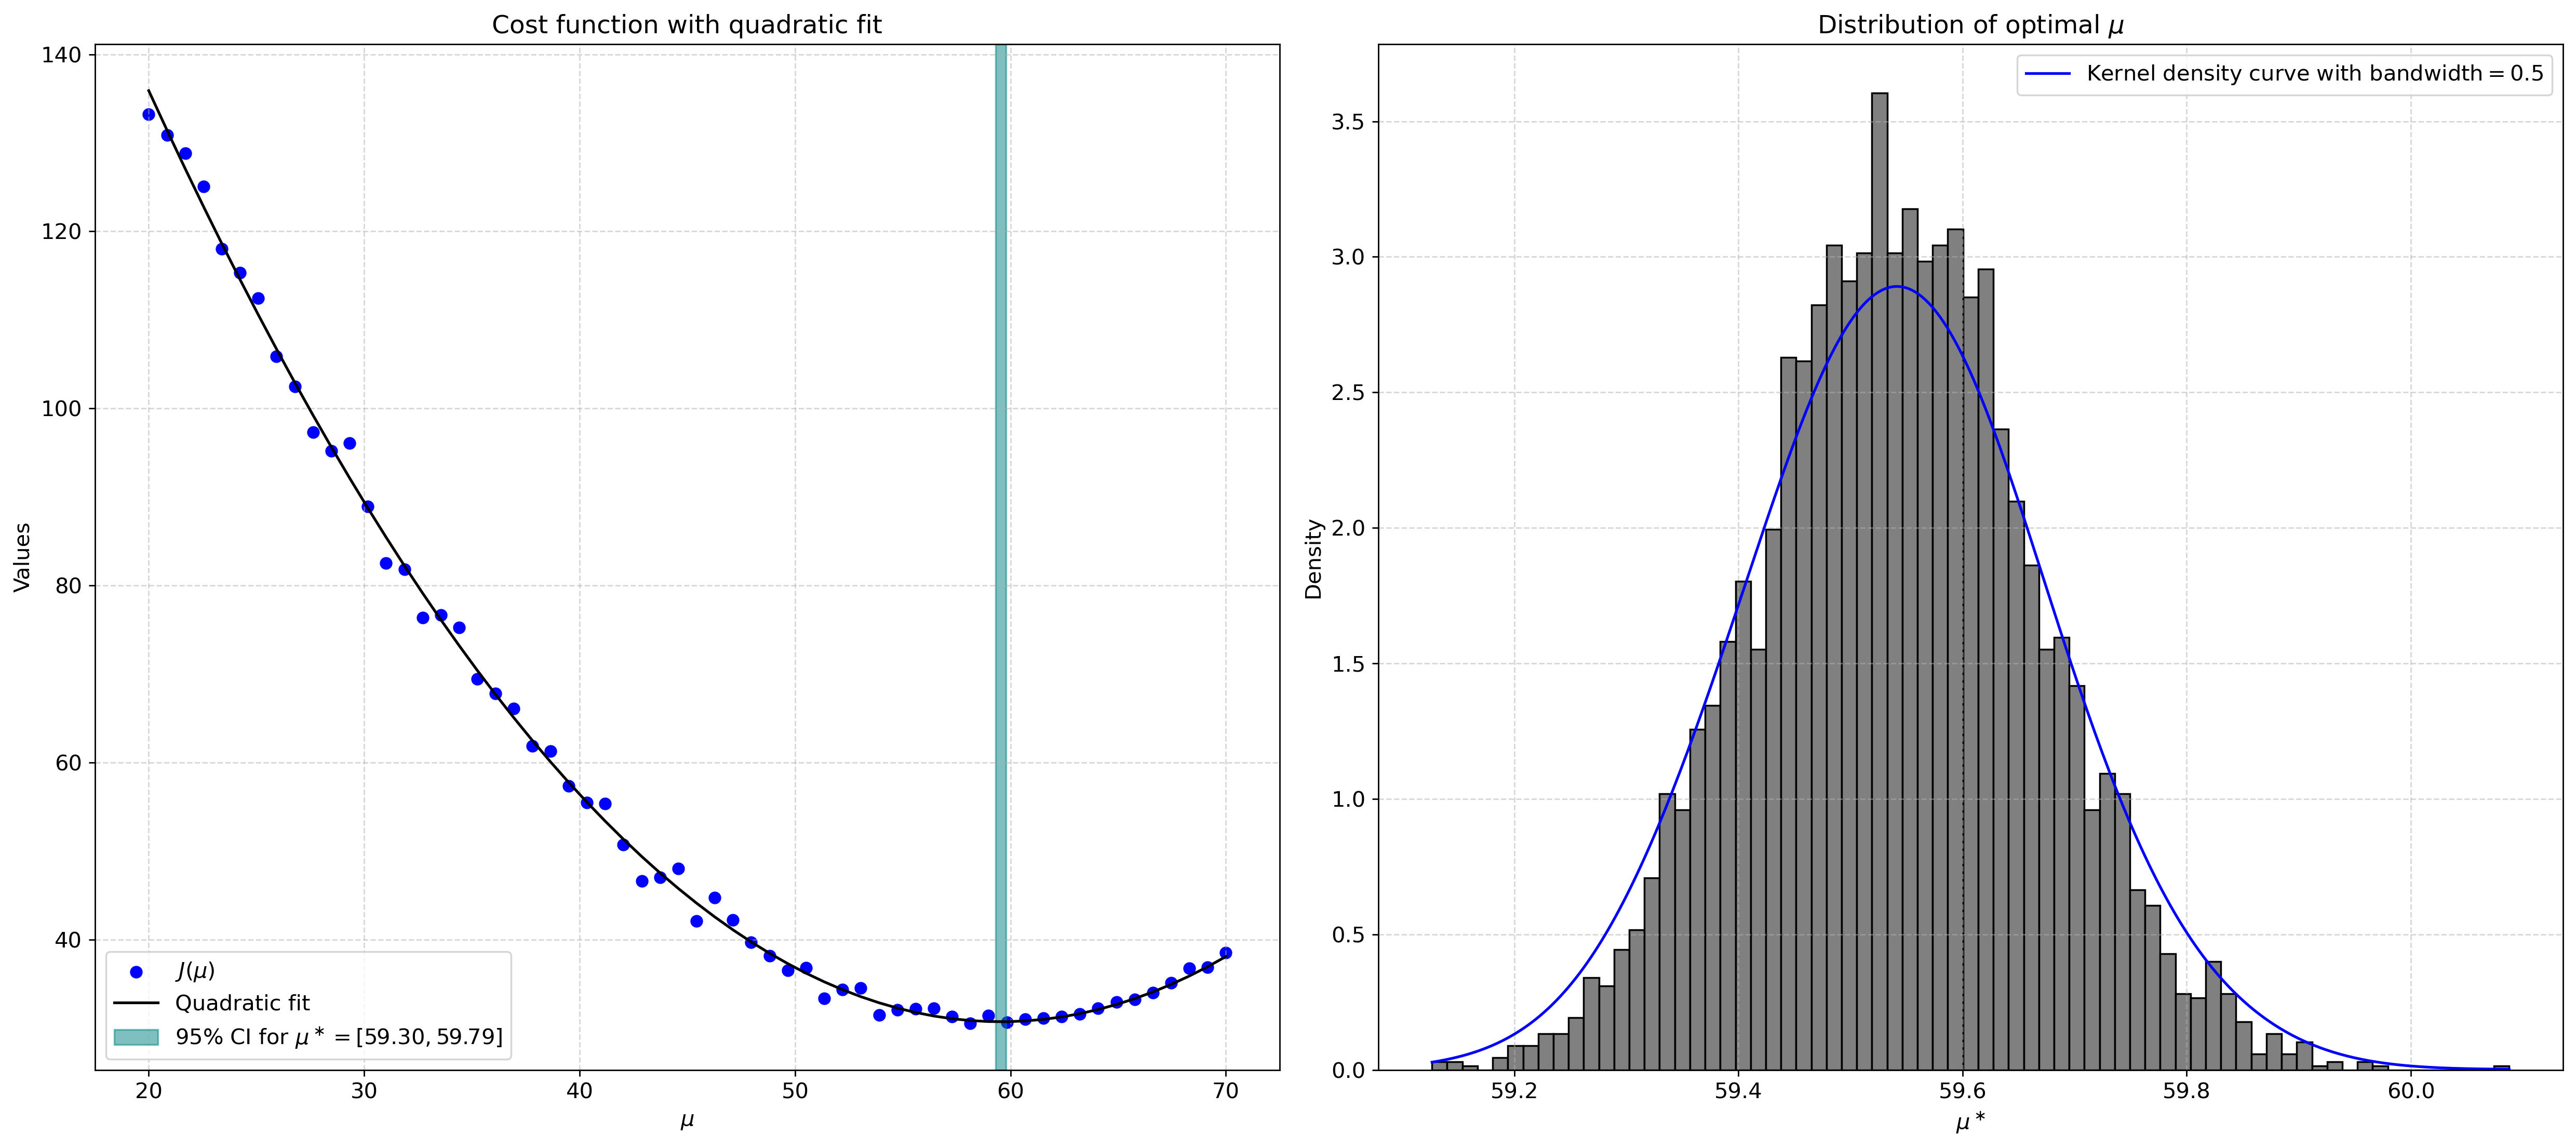

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9), dpi=250)

# ============================================================
#  LEFT PANEL — Quadratic Fit
# ============================================================
ax = axes[0]

ax.scatter(mu_values, J_mu_boot1, color='blue', label=r"$J(\mu)$")

ax.plot(mu_values, Y_Q_fit1.mean(axis=0), color ='black', label=r'Quadratic fit')

CI1 = np.quantile(mu_star_samples1, [0.025, 0.975])        # 95% CI
ax.axvspan(CI1[0], CI1[1], color='Teal', alpha=0.5, label=fr'$95\%$ CI for $\mu^\ast = [{CI1[0]:.2f}, {CI1[1]:.2f}]$')

ax.set_xlabel(r"$\mu$")
ax.set_ylabel("Values")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()
ax.set_title("Cost function with quadratic fit")

# ============================================================
#  RIGHT PANEL — Histogram
# ============================================================
ax = axes[1]

n = len(mu_star_samples1)
bins = int(np.ceil(np.sqrt(n)))
ax.hist(mu_star_samples1, bins=bins, density=True, color='gray',edgecolor='black', alpha=1)
# ax.axvline(mu_star1, color='Teal', linestyle='--', label=fr'Exact $\mu^\ast = {mu_star1:.2f}$')

# KDE
kde = gaussian_kde(mu_star_samples1, bw_method=0.5)
x = np.linspace(min(mu_star_samples1), max(mu_star_samples1), 300)
ax.plot(x, kde(x), color="blue", linewidth=1.5, label="Kernel density curve with bandwidth$=0.5$")

ax.set_title(r"Distribution of optimal $\mu$")

# ax.title(r"Bootstrap distribution of optimal $\mu$")
ax.set_xlabel(r"$\mu^\ast$")
ax.set_ylabel("Density")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

# ============================================================
#  Formatting
# ============================================================
plt.tight_layout()
plt.savefig("Optimise_mu2_Gillespie.png", format='png', bbox_inches='tight')
plt.show()


# - To find the optimal $\mu$ at $95\%$ 

## Objective function:  $\min_{\mu \ge 0} J(\mu) = h \int_{0}^{T}\mathbb{E}[X(t)]dt + \frac{\kappa}{2}\left[\mathbb{E}(Y(T))- M_T\right]^2 + \alpha \mu$ using Gillespie Algorithm based on pathwise bootstrap approach 


### Note $\int_{0}^{T}\mathbb{E}[X(t)]dt = \mathbb{E}\left[\int_{0}^{T}X(t)dt\right] \approx \mathbb{E}\left[\sum_{i=0}^{T-1}X_i\left(t_{i+1}-t_i\right)\right]$

### $\int_{0}^{T}\mathbb{E}[X(t)]dt \approx \frac{1}{M}\sum_{m=1}^M\left[\sum_{i=0}^{T-1}X_i^{(m)}\left(t_{i+1}-t_i\right)\right]$

# - Bootstrap with quadratic fit

In [74]:
# ============================================================
# Bootstrap estimator for mu*
# ============================================================
def bootstrap_quadratic_fit2(mu_values, init_state, vectors, T, num_runs, Demand, alpha, h, kappa, B):
    Y_T_mu2 = {}                      # Store rdv of Y(T) to resmaple from later
    EX_int2 = {}                      # Store rdv of int X(t) dt to resmaple from later
    
    for mu in mu_values:
        EX_integrals2 = estimate_integral_EX(mu, init_state, vectors, T, num_runs)
        EX_int2[mu] = EX_integrals2
        Y_T2 = estimate_E_YT(mu, init_state, vectors, T, num_runs)
        Y_T_mu2[mu] = Y_T2
       

# ============================================================
    # Bootstrap resamples with replacement
# ============================================================
    mu_star_samples2 = np.zeros(B)
    Y_Q_fit2 = np.zeros((B, len(mu_values)))
    n = num_runs
    
    for b in range(B):
        J_mu_boot2 = []
        
        for mu in mu_values:
            X_t2 = np.random.choice(EX_int2[mu], size=n, replace=True)
            Y_T2 = np.random.choice(Y_T_mu2[mu], size=n, replace=True)
            
            EX2 = np.mean(X_t2)
            EY_T2 = np.mean(Y_T2)
            
            J_mu2 = h*EX2 +(kappa/2)* (EY_T2 - Demand)**2 + alpha*mu
            J_mu_boot2.append(J_mu2)

        J_mu_boot2 = np.array(J_mu_boot2)
        
        # =========== Quadratic fit ===========
        a2, a1, a0 = np.polyfit(mu_values, J_mu_boot2, 2)

        # =========== store results a_0 + a_1*mu + a_2*mu^2 ===========
        Y_Q_fit2[b, :]  = a0 + a1*mu_values + a2*mu_values**2
        
        # ============================================================
        # Optimal mu
        # ============================================================    
        mu_star_samples2[b] = - a1/(2*a2)
                
    return Y_Q_fit2, J_mu_boot2, np.array(mu_star_samples2)

# - Exact optimal mu
def exact_optimal_mu2(x_0, y_0, T, lam, h, kappa, alpha, Demand):
    A = T + ((np.exp(-lam*T)-1)/lam)
    B = Demand + (x_0*(np.exp(-lam*T)-1)) - y_0

    # exact optimal mu
    mu_star2 = B/A - (1/(kappa*A**2))*(alpha + (h*A/lam))
    return mu_star2

# - Print out

In [75]:
# # ============================================================
# # Parameters
# # ============================================================
alpha = 0.5                            # control penalty
h, kappa = 0.5 , 0.5                   # holding cost/unit, unit penalty for deviating from costumer demand
mu_values = np.linspace(20, 70, 60)

mu_star2 = exact_optimal_mu2(x_0, y_0, T, lam, h, kappa, alpha, Demand)
Y_Q_fit2, J_mu_boot2, mu_star_samples2 = bootstrap_quadratic_fit2(mu_values, init_state, vectors, T, num_runs, Demand, alpha, h, kappa, B)

# - Plot

In [87]:
# ============================================================
# Plot mu vs J(mu) and Quadratic fit
# ============================================================
plt.figure(figsize=(10, 6))

plt.scatter(mu_values, J_mu_boot2, color='blue', label=r"$J(\mu)$")

plt.plot(mu_values, Y_Q_fit2.mean(axis=0), color ='black', label=r'Quadratic fit')

CI2 = np.quantile(mu_star_samples2, [0.025, 0.975])        # 95% CI
plt.axvspan(CI2[0], CI2[1], color='Teal', alpha=0.5, label=fr'$95\%$ CI for $\mu^\ast = [{CI2[0]:.2f}, {CI2[1]:.2f}]$')

plt.xlabel(r'$\mu$')
plt.ylabel(r'Values')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# - Histogram

In [89]:
n = len(mu_star_samples2)
bins = int(np.ceil(np.sqrt(n)))
plt.figure(figsize=(10, 6))
plt.hist(mu_star_samples2, bins=bins, density=True, color='gray',edgecolor='black', alpha=1)

# KDE
kde = gaussian_kde(mu_star_samples2, bw_method=0.5)
x = np.linspace(min(mu_star_samples2), max(mu_star_samples2), 300)
plt.plot(x, kde(x), color="blue", linewidth=1.5, label="Kernel density curve with bandwidth$=0.5$")

plt.title(r"Bootstrap distribution of optimal $\mu$")
plt.xlabel(r"$\mu^\ast$")
plt.ylabel("Density")
# plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Plot for the cost function with quadratic fit and Distribution of the optimal mu

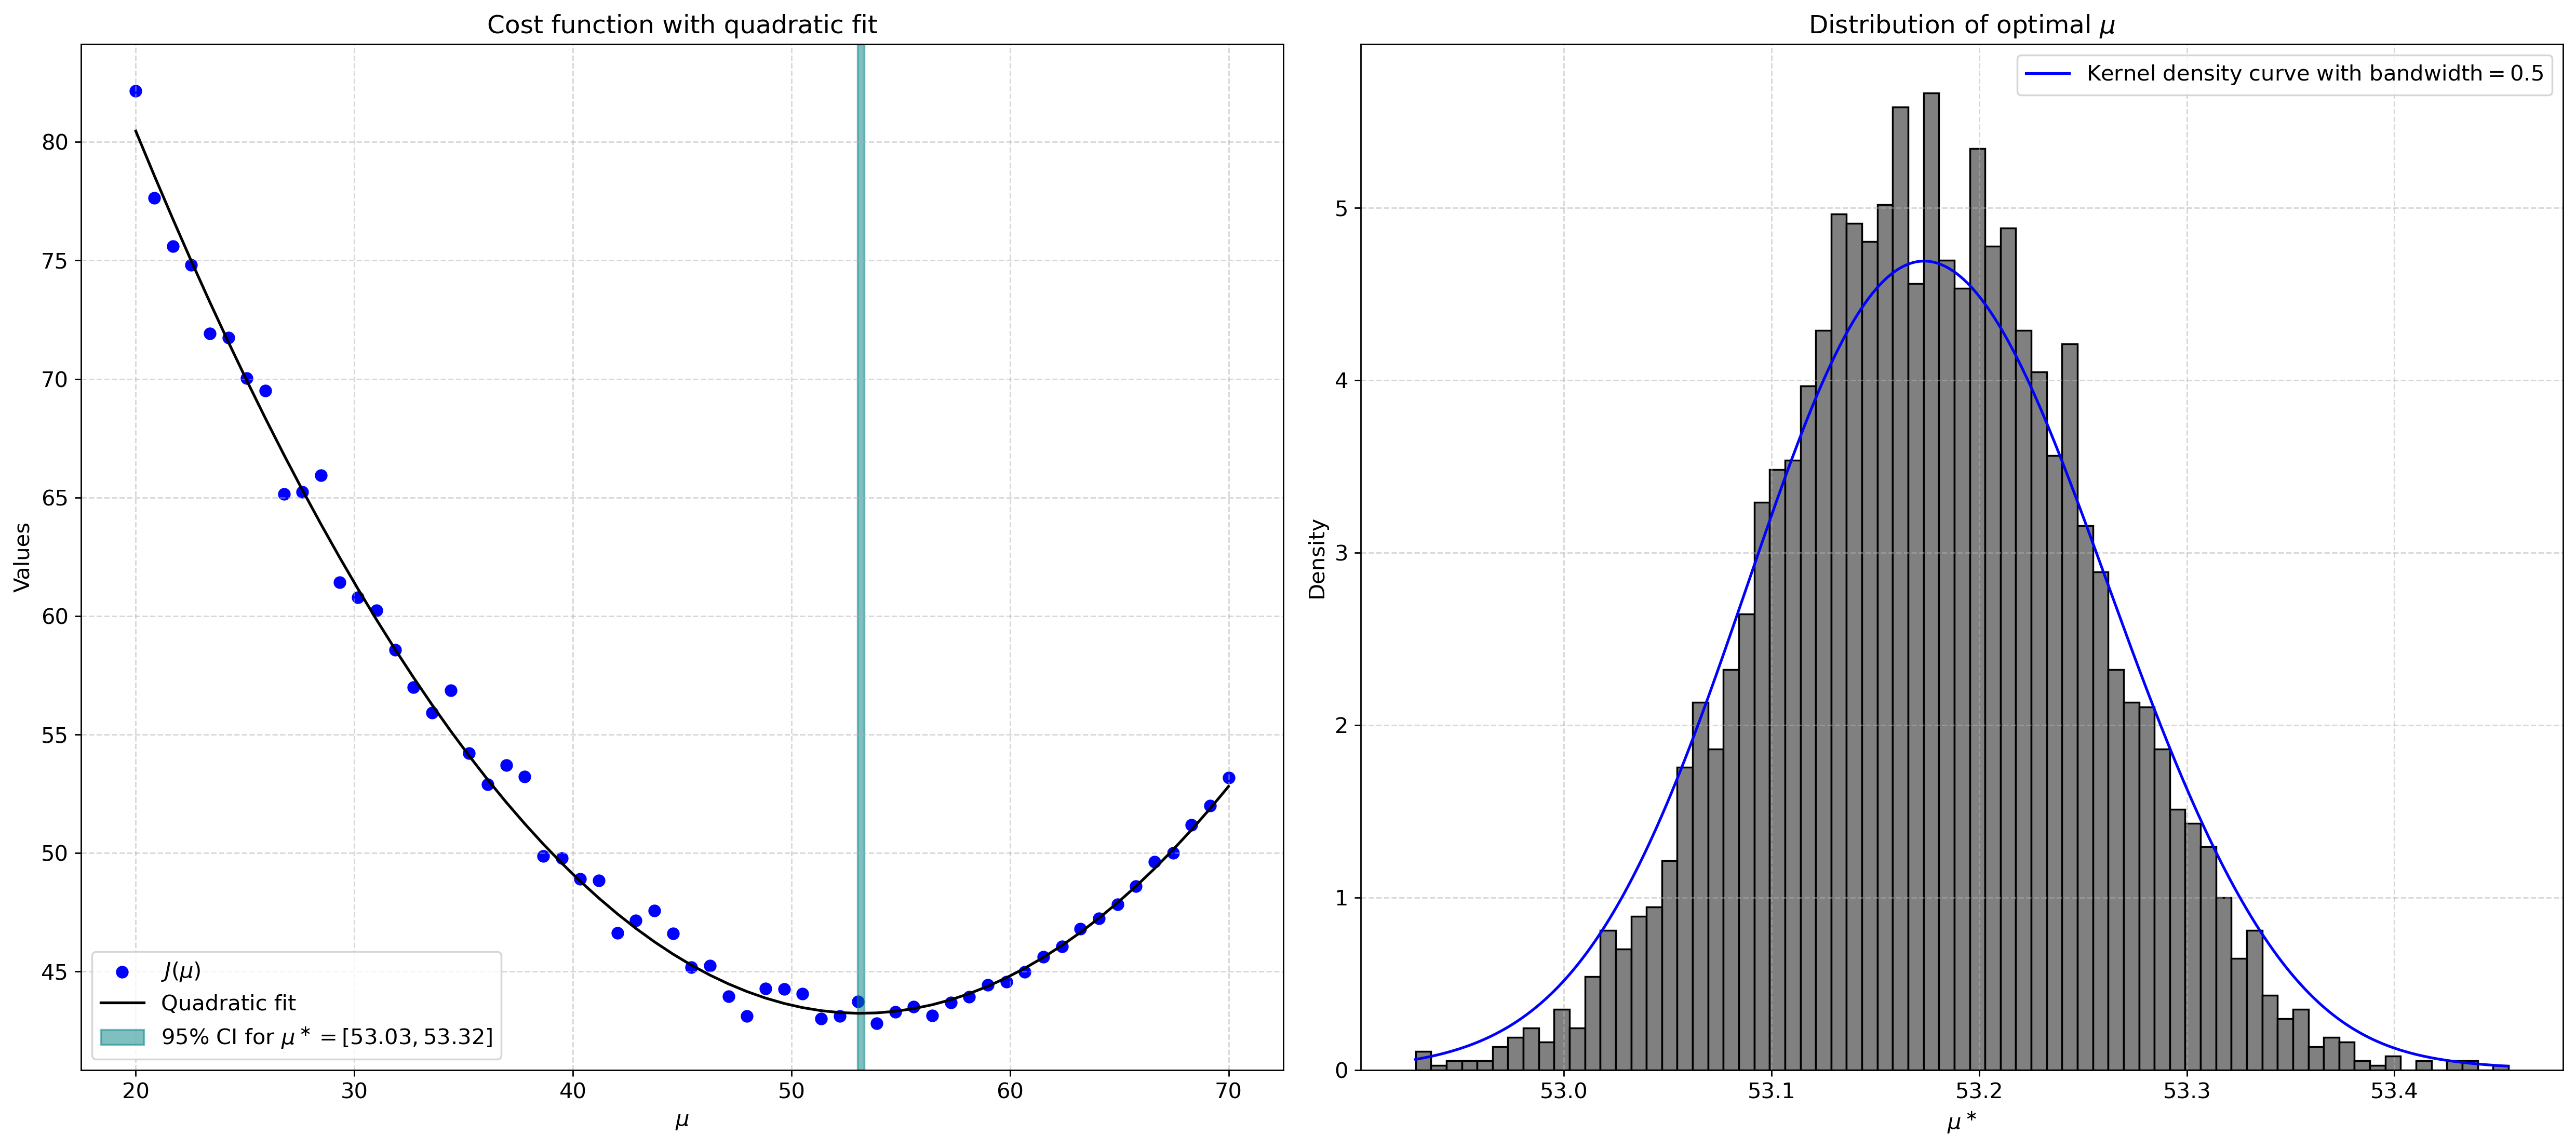

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9), dpi=250)

# ============================================================
#  LEFT PANEL — Quadratic Fit
# ============================================================
ax = axes[0]

ax.scatter(mu_values, J_mu_boot2, color='blue', label=r"$J(\mu)$")

ax.plot(mu_values, Y_Q_fit2.mean(axis=0), color ='black', label=r'Quadratic fit')

CI1 = np.quantile(mu_star_samples2, [0.025, 0.975])        # 95% CI
ax.axvspan(CI1[0], CI1[1], color='Teal', alpha=0.5, label=fr'$95\%$ CI for $\mu^\ast = [{CI1[0]:.2f}, {CI1[1]:.2f}]$')

ax.set_xlabel(r"$\mu$")
ax.set_ylabel("Values")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()
ax.set_title("Cost function with quadratic fit")


# ============================================================
#  RIGHT PANEL — Histogram
# ============================================================
ax = axes[1]

n = len(mu_star_samples2)
bins = int(np.ceil(np.sqrt(n)))
ax.hist(mu_star_samples2, bins=bins, density=True, color='gray',edgecolor='black', alpha=1)

# KDE
kde = gaussian_kde(mu_star_samples2, bw_method=0.5)
x = np.linspace(min(mu_star_samples2), max(mu_star_samples2), 300)
ax.plot(x, kde(x), color="blue", linewidth=1.5, label="Kernel density curve with bandwidth$=0.5$")

ax.set_title(fr"Distribution of optimal $\mu$")
ax.set_xlabel(r"$\mu^\ast$")
ax.set_ylabel("Density")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

# ============================================================
#  Formatting
# ============================================================
plt.tight_layout()
plt.savefig("Optimise_mu3_Gillespie.png", format='png', bbox_inches='tight')
plt.show()


# - To find the optimal $\mu$
## Objective function: $\min_{\mu \ge 0} J(\mu) = h \int_{0}^{T}\mathbb{E}[X(t;\mu)]dt + \frac{\kappa}{2}\left[\mathbb{E}(Y(T;\mu))- M_T\right]^2 + \alpha \mu$  

## Subj. to: $\mathbb{E}[Y(T;\mu)] \ge M_T$ using Gillespie Algorithm

# - Bootstrap with Linear and Quadratic fit

In [79]:
# ============================================================
# Bootstrap estimator for mu*
# ============================================================
def bootstrap3(mu_values, init_state, vectors, T, num_runs, Demand, alpha, h, kappa, B):
    Y_T_mu3 = {}                                                 # Store rdv of Y(T) to resmaple from later
    X_int3 = {}                                                 # Store rdv of int X(t) dt to resmaple from later
    EY_values3 = {}                                              # Store the E(Y(T))
    
    for mu in mu_values:
        X_t3 = estimate_integral_EX(mu, init_state, vectors, T, num_runs)
        X_int3[mu] = X_t3
        Y_T3 = estimate_E_YT(mu, init_state, vectors, T, num_runs)
        Y_T_mu3[mu] = Y_T3
        EY_values3[mu] = np.mean(Y_T3)
       

# ============================================================
    # Bootstrap resamples with replacement
# ============================================================
    mu_star_samples3 = np.zeros(B)
    Y_fit_linear = np.zeros((B, len(mu_values)))
    Y_fit_quadratic = np.zeros((B, len(mu_values)))
    n = num_runs
    
    for b in range(B):
        EY_boot3 = []
        
        J_mu_boot3 = []
        
        for mu in mu_values:
            X_samples = np.random.choice(X_int3[mu], size=n, replace=True)           # resample from X(t) dt with replacement
            Y_samples = np.random.choice(Y_T_mu3[mu], size=n, replace=True)         # resample from Y(T) with replacement

            EX3 = np.mean(X_samples)
            EY_T3 = np.mean(Y_samples)
            EY_boot3.append(EY_T3)
                
            J_mu3 = h*EX3 + (kappa/2)* (EY_T3 - Demand)**2 + alpha*mu
            J_mu_boot3.append(J_mu3)

        EY_boot3 = np.array(EY_boot3)
        J_mu_boot3 = np.array(J_mu_boot3)

        
        # store results
        # ---------- Linear regression (slope3*mu_values + intercept3)----------
        slope3, intercept3 = np.polyfit(mu_values, EY_boot3, 1)
        Y_fit_linear[b, :]  = slope3*mu_values + intercept3
        
        # ---------- Quadratic fit ----------
        a2, a1, a0 = np.polyfit(mu_values, J_mu_boot3, 2)

        # store results a_0 + a_1*mu + a_2*mu^2
        Y_fit_quadratic[b, :]  = a0 + a1*mu_values + a2*mu_values**2


        # ---------- Solve for mu* ----------
        if slope3 != 0:
            mu_star = (Demand - intercept3) / slope3
            mu_star_samples3[b] = mu_star 

    return Y_fit_linear, Y_fit_quadratic, J_mu_boot3, EY_boot3, np.array(mu_star_samples3)

# - Exact optimal mu
def exact_optimal_mu3(x_0, y_0, T, lam, h, kappa, alpha, Demand, eta1, eta2):
    A = T + ((np.exp(-lam*T)-1)/lam)
    B = Demand + (x_0*(np.exp(-lam*T)-1)) - y_0
    D = eta1 + eta2*A - alpha - h*A/lam

    # exact optimal mu
    mu_star3 = (B + D/(kappa*A))/A
    return mu_star3

# - Print out

In [80]:

# ============================================================
# Parameters
# ============================================================
alpha = 0.5                            # control penalty
eta1, eta2 = 0.5, 0.5                  # Lagrange multipliers
h, kappa = 0.5 , 0.5                   # holding cost/unit, unit penalty for deviating from costumer demand
mu_values = np.linspace(20, 70, 60)

mu_star3 = exact_optimal_mu3(x_0, y_0, T, lam, h, kappa, alpha, Demand, eta1, eta2)
Y_fit_lin, Y_fit_quad, J_mu_boot3, EY_boot3, mu_star_samples3 = bootstrap3(mu_values, init_state, vectors, 
                                                                                   T, num_runs, Demand, alpha, h, kappa, B)


# - Plot

In [85]:
# ============================================================
# Plot mu vs J(mu), Linear and Quadratic fit
# ============================================================
plt.figure(figsize=(10, 6))

plt.scatter(mu_values, J_mu_boot3, color ='Blue', label=r'$J(\mu)$')
plt.plot(mu_values, Y_fit_quad.mean(axis=0), color ='black', label=r'Quadratic fit')

plt.scatter(mu_values, EY_boot3, color ='red', label=r'$\mathbb{E}\left(Y(T;\mu)\right)$')
plt.plot(mu_values, Y_fit_lin.mean(axis=0), color ='orange', label=r'Linear fit')
plt.axhline(Demand, color='green', linestyle='--', label=r'$M_T$')
ax.axvline(mu_star3, color='purple', linestyle=':', label=fr'$\mu^\ast_{{\rm exact}} = {mu_star3:.2f}$', alpha=1)


CI3 = np.quantile(mu_star_samples3, [0.025, 0.975])        # 95% CI
plt.axvspan(CI3[0], CI3[1], color='Teal', alpha=0.3, label=fr'$95\%$ CI for $\mu^\ast = [{CI3[0]:.2f}, {CI3[1]:.2f}]$')

plt.xlabel(r'$\mu$')
plt.ylabel(r'Values')
# plt.title(r'')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# - Histogram

In [84]:
n = len(mu_star_samples3)
bins = int(np.ceil(np.sqrt(n)))
plt.figure(figsize=(10, 6))
plt.hist(mu_star_samples3, bins=bins, density=True, color='gray',edgecolor='black', alpha=1)

# KDE
kde = gaussian_kde(mu_star_samples3, bw_method=0.5)
x = np.linspace(min(mu_star_samples3), max(mu_star_samples3), 300)
plt.plot(x, kde(x), color="blue", linewidth=1.5, label="Kernel density curve with bandwidth$=0.5$")

plt.title(r"Bootstrap distribution of optimal $\mu$")
plt.xlabel(r"$\mu^\ast$")
plt.ylabel("Density")
# plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# The plot for the cost function with quadratic fit & $\mathbb{E}\left(Y(T;\mu)\right)$ with lineear fit and distribution for the optimal mu

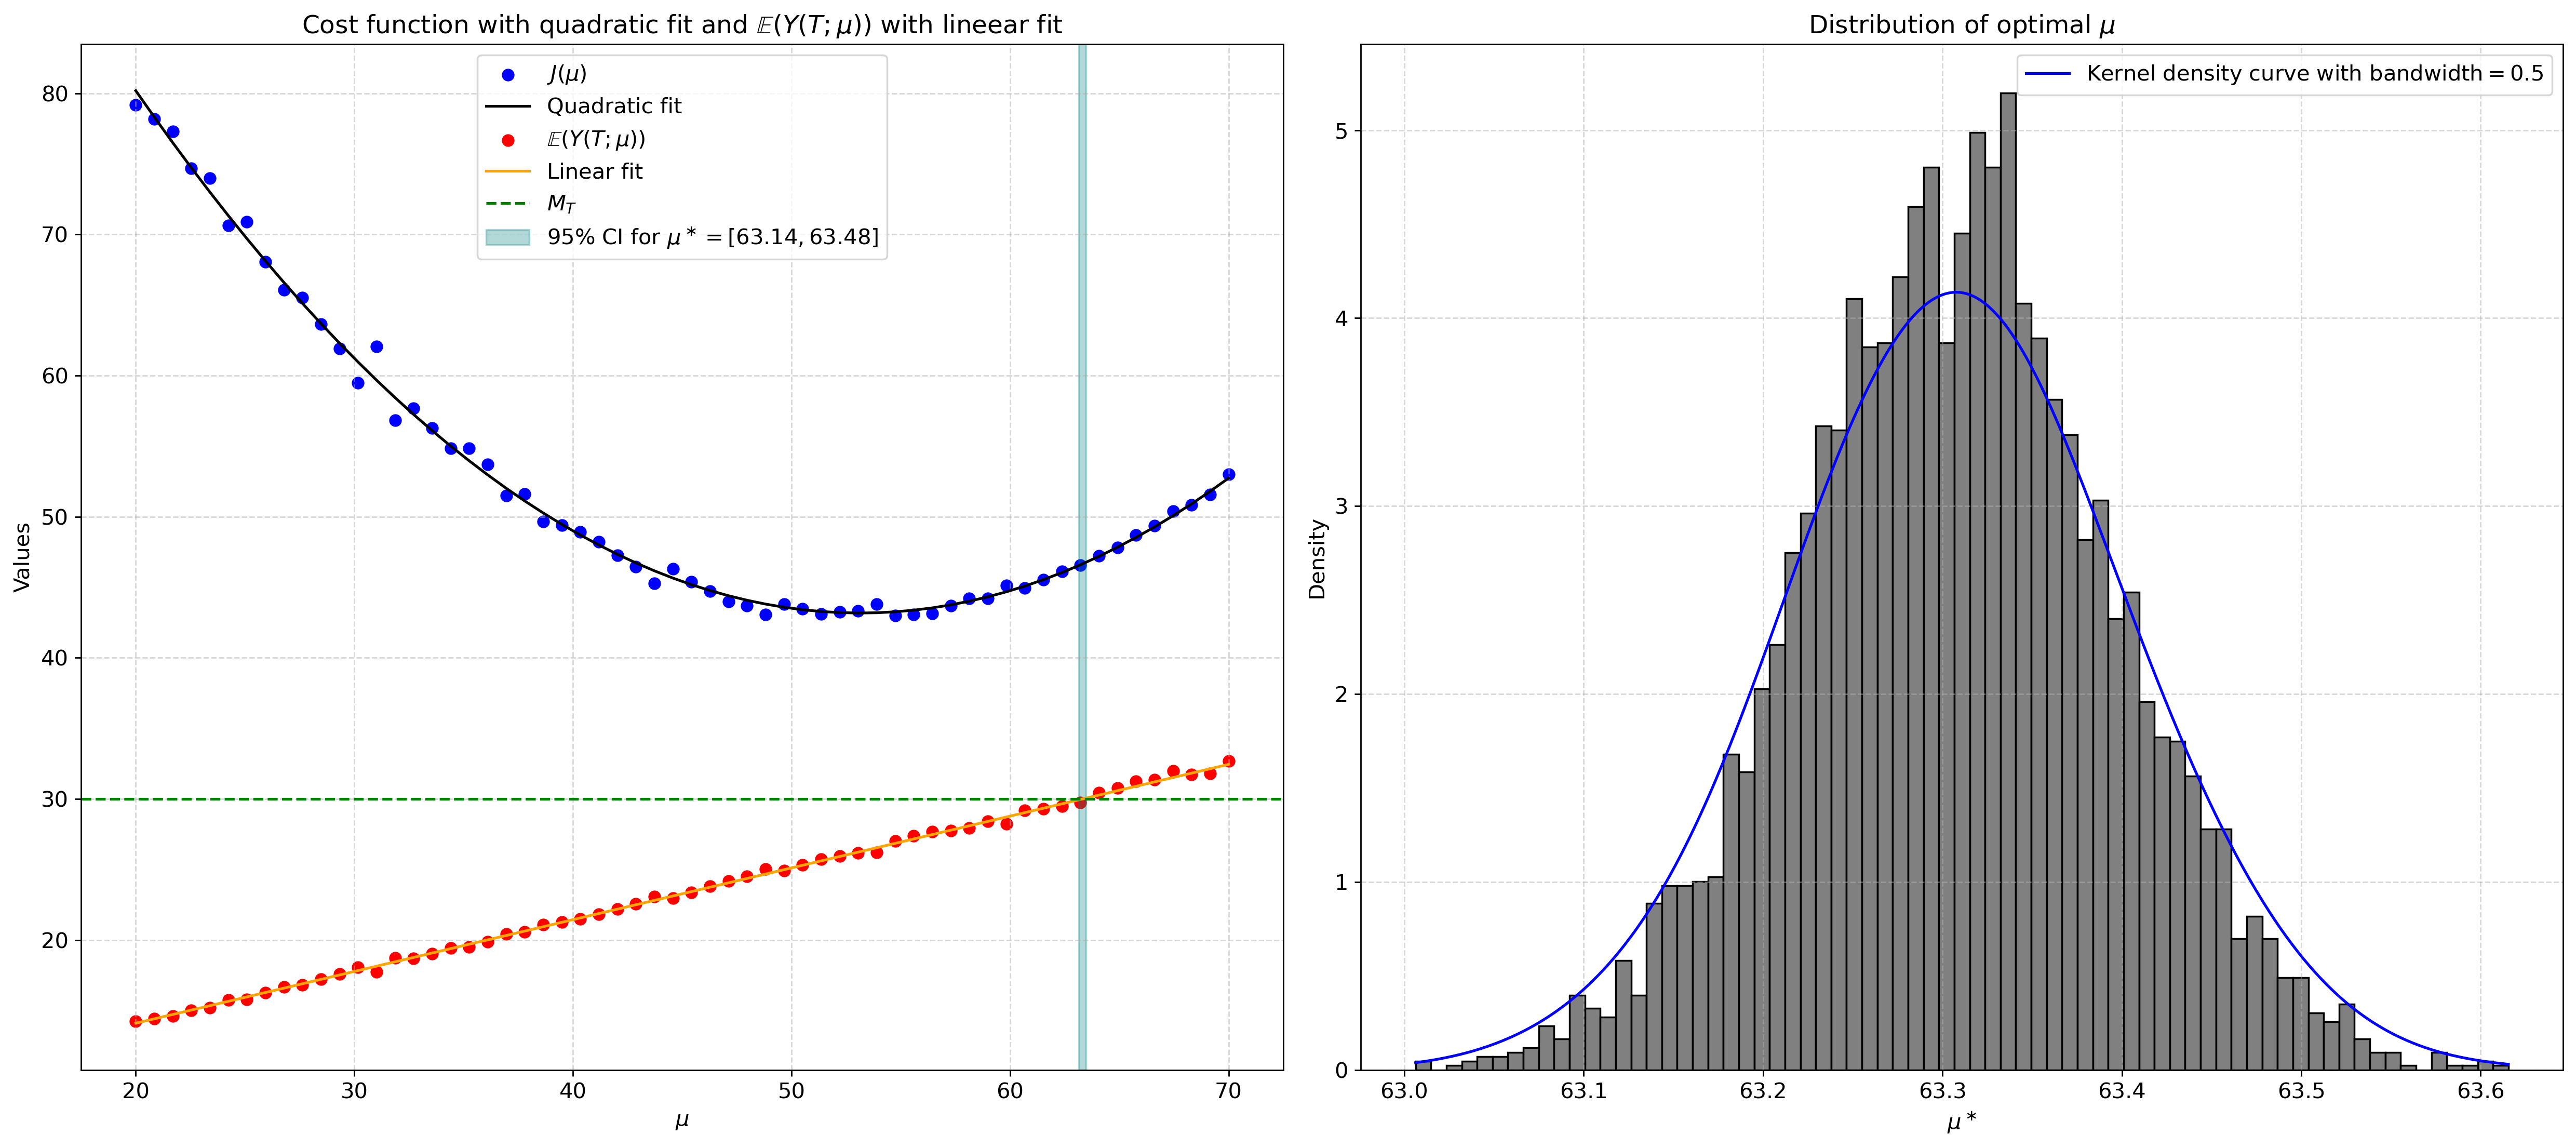

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9), dpi=250)

# ============================================================
#  LEFT PANEL — Quadratic Fit
# ============================================================
ax = axes[0]

ax.scatter(mu_values, J_mu_boot3, color ='Blue', label=r'$J(\mu)$')
ax.plot(mu_values, Y_fit_quad.mean(axis=0), color ='black', label=r'Quadratic fit')

ax.scatter(mu_values, EY_boot3, color ='red', label=r'$\mathbb{E}\left(Y(T;\mu)\right)$')
ax.plot(mu_values, Y_fit_lin.mean(axis=0), color ='orange', label=r'Linear fit')


ax.axhline(Demand, color='green', linestyle='--', label=r'$M_T$')


CI3 = np.quantile(mu_star_samples3, [0.025, 0.975])        # 95% CI
ax.axvspan(CI3[0], CI3[1], color='Teal', alpha=0.3, label=fr'$95\%$ CI for $\mu^\ast = [{CI3[0]:.2f}, {CI3[1]:.2f}]$')

ax.set_xlabel(r"$\mu$")
ax.set_ylabel("Values")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()
ax.set_title(r"Cost function with quadratic fit and $\mathbb{E}\left(Y(T;\mu)\right)$ with lineear fit")


# ============================================================
#  RIGHT PANEL — Histogram
# ============================================================
ax = axes[1]

n = len(mu_star_samples3)
bins = int(np.ceil(np.sqrt(n)))
ax.hist(mu_star_samples3, bins=bins, density=True, color='gray',edgecolor='black', alpha=1)
# KDE
kde = gaussian_kde(mu_star_samples3, bw_method=0.5)
x = np.linspace(min(mu_star_samples3), max(mu_star_samples3), 300)
ax.plot(x, kde(x), color="blue", linewidth=1.5, label="Kernel density curve with bandwidth$=0.5$")

ax.set_title(fr"Distribution of optimal $\mu$")
ax.set_xlabel(r"$\mu^\ast$")
ax.set_ylabel("Density")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

# ============================================================
#  Formatting
# ============================================================
plt.tight_layout()

plt.savefig("Optimise_mu4_Gillespie.png", format='png', bbox_inches='tight')
plt.show()